In [1]:
start = 0.00025
end = 0.34
# n = 401
# step = (end - start) / (n - 1)
step = 0.00075
n = int((end - start) / step + 1)
print(n, type(n))
FLEX_STRENGTH_values = [round(start + i * step, 5) for i in range(n)]

454 <class 'int'>


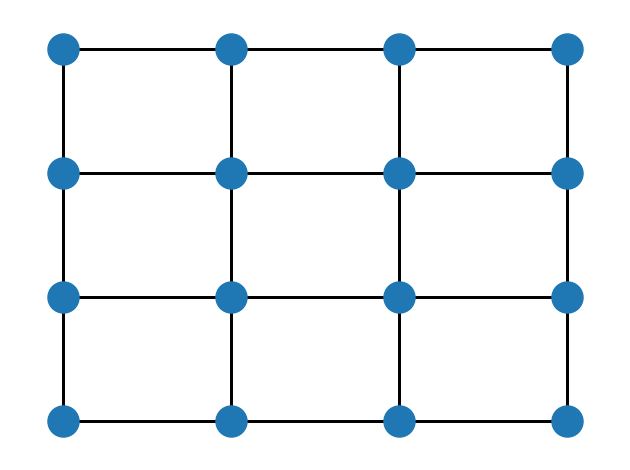

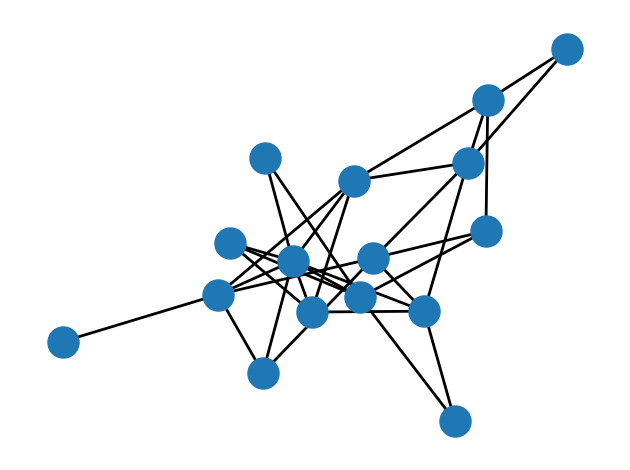

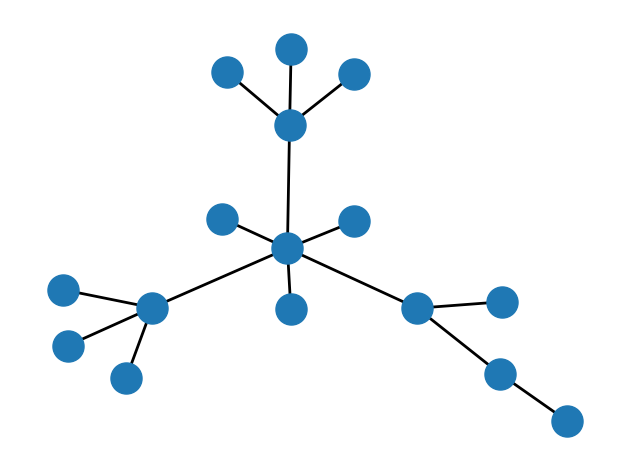

In [152]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(1)
N=16
Gs = nx.grid_2d_graph(int(np.sqrt(N)), int(np.sqrt(N)), periodic=True)
GBA = nx.barabasi_albert_graph(N, m=1)
GER = nx.erdos_renyi_graph(N, p=0.2)

pos_grid = {node: node for node in Gs.nodes()}
pos_ba   = nx.spring_layout(GBA, seed=1)
pos_er   = nx.spring_layout(GER, seed=1)

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(Gs, pos=pos_grid, ax=ax, node_size=500, width=2)
# ax.set_title("2D Square Grid", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_square_graphs.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(GER, pos=pos_er, ax=ax, node_size=500, width=2)
# ax.set_title("ER graph", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_ER_graphs.png")
plt.show()

fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(GBA, pos=pos_ba, ax=ax, node_size=500, width=2)
# ax.set_title("BA graph", fontsize=20)
plt.tight_layout()
plt.savefig(r"plots\visualization\example_BA_graphs.png")
plt.show()

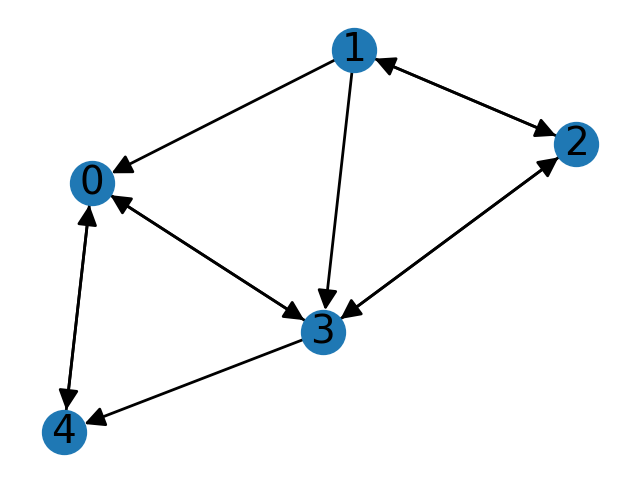

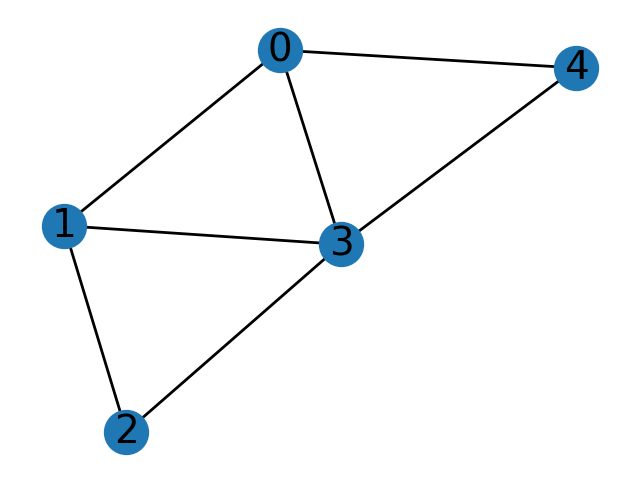

In [157]:
# Gdir = nx.erdos_renyi_graph(5, p=0.5, directed=True)
# Gundir = nx.erdos_renyi_graph(5, p=0.5, directed=False)

Aundir  = np.array([[0., 1., 0., 1., 1.,],
                    [1., 0., 1., 1., 0.,],
                    [0., 1., 0., 1., 0.,],
                    [1., 1., 1., 0., 1.,],
                    [1., 0., 0., 1., 0.,]])

Adir =np.array([[0., 0., 0., 1., 1.,],
                [1., 0., 1., 1., 0.,],
                [0., 1., 0., 1., 0.,],
                [1., 0., 1., 0., 1.,],
                [1., 0., 0., 0., 0.,]])

Gundir = nx.from_numpy_array(Aundir)
Gdir = nx.DiGraph()
rows, cols = np.where(Adir == 1)
edges = zip(rows.tolist(), cols.tolist())
Gdir.add_edges_from(edges)

pos_dir = nx.spring_layout(Gdir, seed=1)
pos_undir = nx.spring_layout(Gundir, seed=1)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
nx.draw(Gdir, pos=pos_dir, ax=ax, node_size=1000, with_labels=True, arrowsize=30, font_size=28, width=2)
# ax.set_title("directed graph", fontsize=20)
plt.savefig(r"plots\visualization\example_dir_graph.png")
plt.show()
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
nx.draw(Gundir, pos=pos_undir, ax=ax, node_size=1000, with_labels=True, font_size=28, width=2)
# ax.set_title("undirected graph", fontsize=20)
plt.savefig(r"plots\visualization\example_undir_graphs.png")
plt.show()

c:\Users\audso\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\audso\anaconda3\Lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


301 301


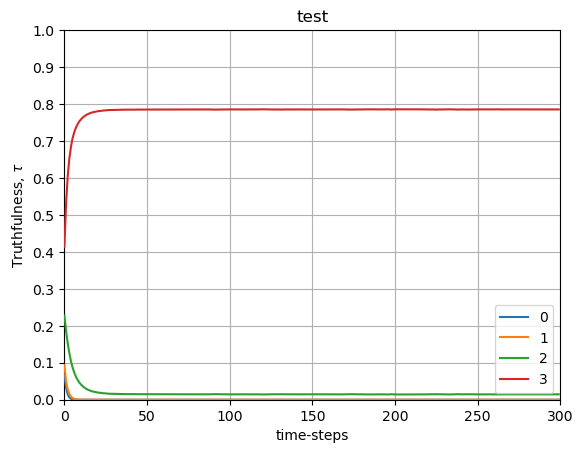

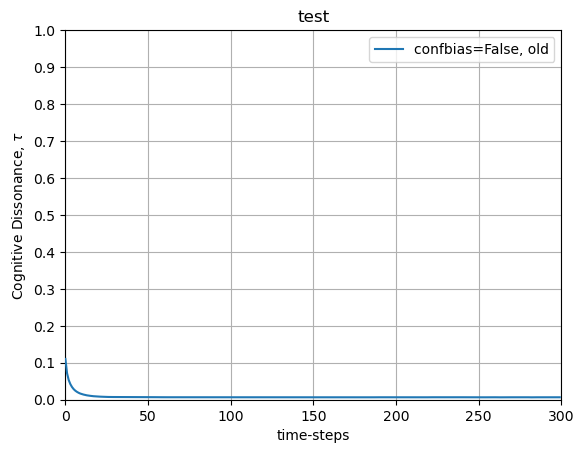

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from metrics import truthfulness, cognitive_dissonance, normalize_each_row_sum
import os

q1 = np.load("visualization\DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_1sims_1.npz")
T = truthfulness(q1['private'], 3)
CD = cognitive_dissonance(q1['private'], q1['public'])
print(len(T), len(CD))

r = np.load(r"resultsbullshittest_DHT_k100_ER_logbeliefs_gaussian_10flex_uniformweights_T300_500sims.npz")
T0 = r['T0']
T1 = r['T1']
T2 = r['T2']
T3 = r['T3']
CD = r['CD']

plt.figure()
plt.plot(np.arange(len(T0[1::])), T0[1::], label=r"0", zorder=5)
plt.plot(np.arange(len(T0[1::])), T1[1::], label=r"1", zorder=5)
plt.plot(np.arange(len(T0[1::])), T2[1::], label=r"2", zorder=5)
plt.plot(np.arange(len(T0[1::])), T3[1::], label=r"3", zorder=5)
plt.grid()
plt.xlim(0, np.max(len(T0[1::])))
plt.xticks(np.arange(0, np.max(len(T0)), 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("test")
# plt.savefig(r"visualization\plots\Truthfulness-graphDHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_T300_1sims.png")
plt.show()

plt.figure()
plt.plot(np.arange(len(CD[1::])), CD[1::], label=r"confbias=False, old", zorder=5)
plt.grid()
plt.xlim(0, np.max(len(T0[1::])))
plt.xticks(np.arange(0, np.max(len(T0)), 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive Dissonance, $\tau$")
plt.title("test")
plt.show()

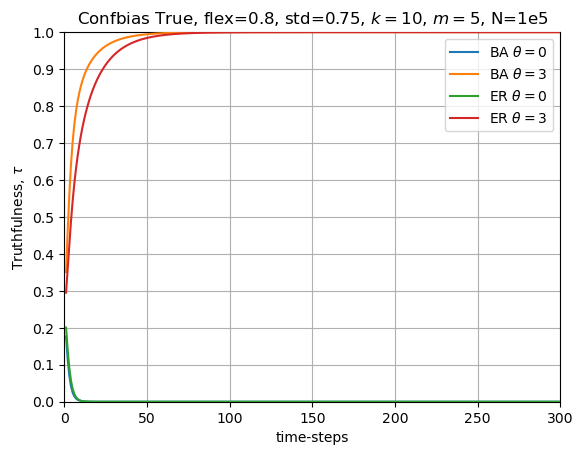

In [4]:
data_BA = np.load(r"N10000\resultsDHT_k1000_BA_m5_gaussian_8flex_uniformweights_T300_20sims_6.npz")
data_ER = np.load(r"N10000\resultsDHT_N10000_k10.0_ER_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_20sims_7.npz")

Tba0 = data_BA["T0"]
Tba3 = data_BA["T3"]
Ter0 = data_ER["T0"]
Ter3 = data_ER["T3"]

t = np.arange(1, len(Tba0))

plt.figure()
plt.plot(t, Tba0[1::], label=r"BA $\theta=0$", zorder=5)
plt.plot(t, Tba3[1::], label=r"BA $\theta=3$", zorder=5)
plt.plot(t, Ter0[1::], label=r"ER $\theta=0$", zorder=5)
plt.plot(t, Ter3[1::], label=r"ER $\theta=3$", zorder=5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title(r"Confbias True, flex=0.8, std=0.75, $k=10$, $m=5$, N=1e5")
# plt.savefig(r"visualization\plots\Truthfulness-graphDHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_T300_1sims.png")
plt.show()

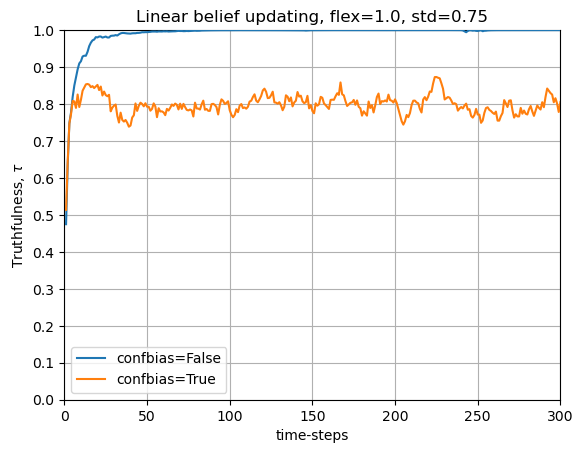

ValueError: x and y must have same first dimension, but have shapes (300,) and (299,)

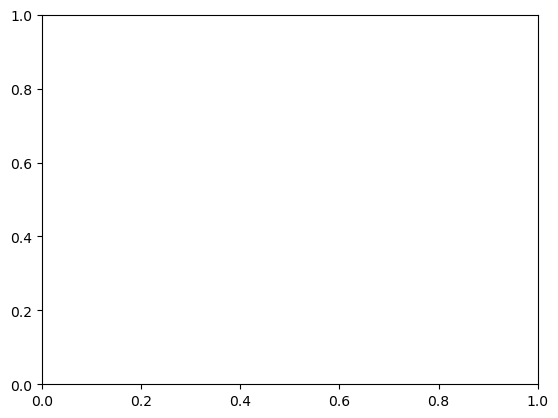

In [2]:
q1 = np.load("visualization\DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_1sims_1.npz")
q2 = np.load("visualization\DHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_1sims_1.npz")
# q3 = np.load("visualization\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
# q4 = np.load("visualization\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_200sims_1.npz")


T1 = truthfulness(q1['private'], 3)
T2 = truthfulness(q2['private'], 3)
# T3 = truthfulness(q3['private'], 3)
# T4 = truthfulness(q4['private'], 3)

CD1 = cognitive_dissonance(q1['private'], q1['public'])
CD2 = cognitive_dissonance(q2['private'], q2['public'])
# CD3 = cognitive_dissonance(q3['private'], q3['public'])
# CD4 = cognitive_dissonance(q4['private'], q4['public'])

t = np.arange(1, len(T1), 1)

plt.figure()
plt.plot(t, T1[1::], label=r"confbias=False", zorder=5)
plt.plot(t, T2[1::], label=r"confbias=True", zorder=5)
# plt.plot(t, T3[1::], label=r"confbias=False, new", zorder=5)
# plt.plot(t, T4[1::], label=r"confbias=True, new", zorder=5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, std=0.75")
plt.savefig(r"visualization\plots\Truthfulness-graphDHT_N100_k10_SQUARE_linbeliefs_gaussian-stds0.75_10flex_T300_1sims.png")
plt.show()

plt.figure()
plt.plot(t, CD1[1::], label=r"confbias=False, old", zorder=5)
plt.plot(t, CD2[1::], label=r"confbias=True, old", zorder=5)
# plt.plot(t, CD3[1::], label=r"confbias=False, new", zorder=5)
# plt.plot(t, CD4[1::], label=r"confbias=True, new", zorder=5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive Dissonance, $\tau$")
plt.title("Linear belief updating, flex=1.0, std=0.75")
plt.show()

In [ ]:
q_098 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_098flex_confbias-True_T2000_200sims_1.npz")
q_0985 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0985flex_confbias-True_T2000_200sims_1.npz")
q_099 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_099flex_confbias-True_T2000_200sims_1.npz")
q_0995 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0995flex_confbias-True_T2000_200sims_1.npz")
q_098_sigmoid = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_098flex_confbias-True_T2000_200sims_2.npz")
q_0985_sigmoid = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0985flex_confbias-True_T2000_200sims_2.npz")
q_099_sigmoid = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_099flex_confbias-True_T2000_200sims_2.npz")
q_0995_sigmoid = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_0995flex_confbias-True_T2000_200sims_2.npz")

T_098 = truthfulness(q_098['private'], 3)
T_0985 = truthfulness(q_0985['private'], 3)
T_099 = truthfulness(q_099['private'], 3)
T_0995 = truthfulness(q_0995['private'], 3)
T_098_sigmoid = truthfulness(q_098_sigmoid['private'], 3)
T_0985_sigmoid = truthfulness(q_0985_sigmoid['private'], 3)
T_099_sigmoid = truthfulness(q_099_sigmoid['private'], 3)
T_0995_sigmoid = truthfulness(q_0995_sigmoid['private'], 3)

CD_098 = cognitive_dissonance(q_098['private'], q_098['public'])
CD_0985 = cognitive_dissonance(q_0985['private'], q_0985['public'])
CD_099 = cognitive_dissonance(q_099['private'], q_099['public'])
CD_0995 = cognitive_dissonance(q_0995['private'], q_0995['public'])
CD_098_sigmoid = cognitive_dissonance(q_098_sigmoid['private'], q_098_sigmoid['public'])
CD_0985_sigmoid = cognitive_dissonance(q_0985_sigmoid['private'], q_0985_sigmoid['public'])
CD_099_sigmoid = cognitive_dissonance(q_099_sigmoid['private'], q_099_sigmoid['public'])
CD_0995_sigmoid = cognitive_dissonance(q_0995_sigmoid['private'], q_0995_sigmoid['public'])

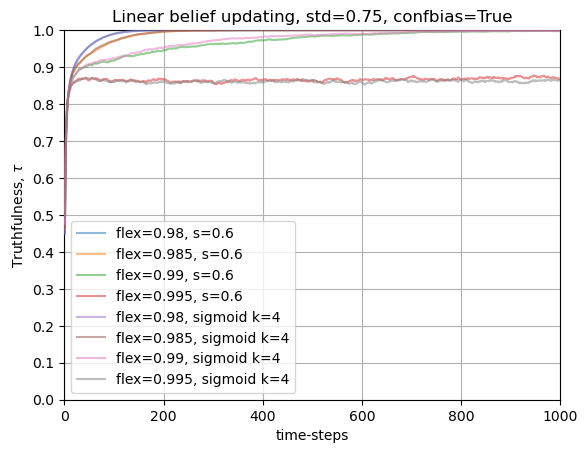

In [5]:
t = np.arange(1, len(T_098)/2, 1)

plt.figure()
plt.plot(t, T_098[1:1001:], label=r"flex=0.98, s=0.6", zorder=5, alpha=0.5)
plt.plot(t, T_0985[1:1001:], label=r"flex=0.985, s=0.6", zorder=6, alpha=0.5)
plt.plot(t, T_099[1:1001:], label=r"flex=0.99, s=0.6", zorder=7, alpha=0.5)
plt.plot(t, T_0995[1:1001:], label=r"flex=0.995, s=0.6", zorder=8, alpha=0.5)
plt.plot(t, T_098_sigmoid[1:1001:], label=r"flex=0.98, sigmoid k=4", zorder=9, alpha=0.5)
plt.plot(t, T_0985_sigmoid[1:1001:], label=r"flex=0.985, sigmoid k=4", zorder=10, alpha=0.5)
plt.plot(t, T_099_sigmoid[1:1001:], label=r"flex=0.99, sigmoid k=4", zorder=11, alpha=0.5)
plt.plot(t, T_0995_sigmoid[1:1001:], label=r"flex=0.995, sigmoid k=4", zorder=12, alpha=0.5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 200))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, std=0.75, confbias=True")
plt.show()

In [3]:
q_std05_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.5_08flex_confbias-True_T300_200sims_1.npz")
q_std075_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.75_08flex_confbias-True_T300_200sims_1.npz")
q_std10_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.0_08flex_confbias-True_T300_200sims_1.npz")
q_std125_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.25_08flex_confbias-True_T300_200sims_1.npz")
q_std15_BA = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.5_08flex_confbias-True_T300_200sims_1.npz")

q_std05_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_8flex_confbias-True_T300_200sims_1.npz")
q_std075_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_8flex_confbias-True_T300_200sims_1.npz")
q_std10_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_8flex_confbias-True_T300_200sims_1.npz")
q_std125_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_8flex_confbias-True_T300_200sims_1.npz")
q_std15_ER = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_8flex_confbias-True_T300_200sims_1.npz")

q_std05_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
q_std075_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
q_std10_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
q_std125_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
q_std15_BA_basic = np.load("testing\DHT_N100_k10_BA_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

q_std05_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
q_std075_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
q_std10_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
q_std125_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
q_std15_ER_basic = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

T_std05_BA = truthfulness(q_std05_BA['private'], 3)
T_std075_BA = truthfulness(q_std075_BA['private'], 3)
T_std10_BA = truthfulness(q_std10_BA['private'], 3)
T_std125_BA = truthfulness(q_std125_BA['private'], 3)
T_std15_BA = truthfulness(q_std15_BA['private'], 3)

T_std05_ER = truthfulness(q_std05_ER['private'], 3)
T_std075_ER = truthfulness(q_std075_ER['private'], 3)
T_std10_ER = truthfulness(q_std10_ER['private'], 3)
T_std125_ER = truthfulness(q_std125_ER['private'], 3)
T_std15_ER = truthfulness(q_std15_ER['private'], 3)

T_std05_BA_basic = truthfulness(q_std05_BA_basic['private'], 3)
T_std075_BA_basic = truthfulness(q_std075_BA_basic['private'], 3)
T_std10_BA_basic = truthfulness(q_std10_BA_basic['private'], 3)
T_std125_BA_basic = truthfulness(q_std125_BA_basic['private'], 3)
T_std15_BA_basic = truthfulness(q_std15_BA_basic['private'], 3)

T_std05_ER_basic = truthfulness(q_std05_ER_basic['private'], 3)
T_std075_ER_basic = truthfulness(q_std075_ER_basic['private'], 3)
T_std10_ER_basic = truthfulness(q_std10_ER_basic['private'], 3)
T_std125_ER_basic = truthfulness(q_std125_ER_basic['private'], 3)
T_std15_ER_basic = truthfulness(q_std15_ER_basic['private'], 3)

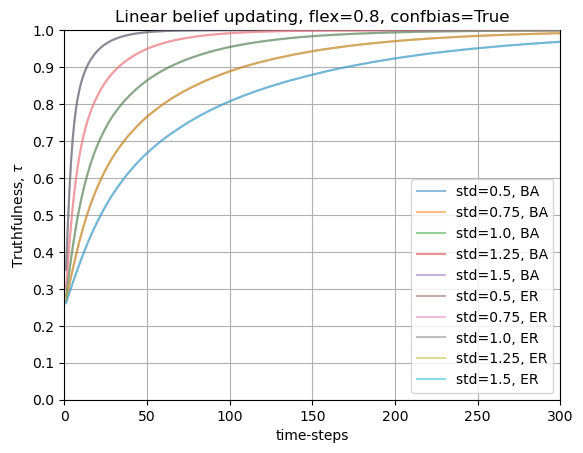

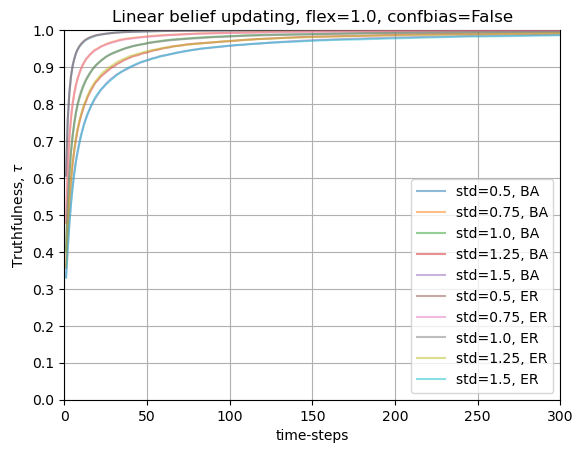

In [4]:
t = np.arange(1, len(T_std05_BA), 1)

plt.figure()
plt.plot(t, T_std05_BA[1::], label=r"std=0.5, BA", zorder=5, alpha=0.5)
plt.plot(t, T_std075_BA[1::], label=r"std=0.75, BA", zorder=6, alpha=0.5)
plt.plot(t, T_std10_BA[1::], label=r"std=1.0, BA", zorder=7, alpha=0.5)
plt.plot(t, T_std125_BA[1::], label=r"std=1.25, BA", zorder=8, alpha=0.5)
plt.plot(t, T_std15_BA[1::], label=r"std=1.5, BA", zorder=9, alpha=0.5)
plt.plot(t, T_std05_ER[1::], label=r"std=0.5, ER", zorder=10, alpha=0.5)
plt.plot(t, T_std075_ER[1::], label=r"std=0.75, ER", zorder=11, alpha=0.5)
plt.plot(t, T_std10_ER[1::], label=r"std=1.0, ER", zorder=12, alpha=0.5)
plt.plot(t, T_std125_ER[1::], label=r"std=1.25, ER", zorder=13, alpha=0.5)
plt.plot(t, T_std15_ER[1::], label=r"std=1.5, ER", zorder=14, alpha=0.5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=0.8, confbias=True")
plt.show()

plt.figure()
plt.plot(t, T_std05_BA_basic[1::], label=r"std=0.5, BA", zorder=5, alpha=0.5)
plt.plot(t, T_std075_BA_basic[1::], label=r"std=0.75, BA", zorder=6, alpha=0.5)
plt.plot(t, T_std10_BA_basic[1::], label=r"std=1.0, BA", zorder=7, alpha=0.5)
plt.plot(t, T_std125_BA_basic[1::], label=r"std=1.25, BA", zorder=8, alpha=0.5)
plt.plot(t, T_std15_BA_basic[1::], label=r"std=1.5, BA", zorder=9, alpha=0.5)
plt.plot(t, T_std05_ER_basic[1::], label=r"std=0.5, ER", zorder=10, alpha=0.5)
plt.plot(t, T_std075_ER_basic[1::], label=r"std=0.75, ER", zorder=11, alpha=0.5)
plt.plot(t, T_std10_ER_basic[1::], label=r"std=1.0, ER", zorder=12, alpha=0.5)
plt.plot(t, T_std125_ER_basic[1::], label=r"std=1.25, ER", zorder=13, alpha=0.5)
plt.plot(t, T_std15_ER_basic[1::], label=r"std=1.5, ER", zorder=14, alpha=0.5)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, confbias=False")
plt.show()

In [5]:
q_std05 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
q_std075 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
q_std10 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
q_std125 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
q_std15 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

q_confbias_std05 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std075 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std10 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std125 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std15 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_10flex_confbias-True_T300_200sims_1.npz")

q_flex08_std05 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std075 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std10 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std125 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std15 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_8flex_confbias-False_T300_200sims_1.npz")

q_confbias_flex08_std05 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.5_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std075 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds0.75_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std10 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.0_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std125 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.25_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std15 = np.load("testing\DHT_N100_k10_ER_linbeliefs_gaussian-stds1.5_8flex_confbias-True_T300_200sims_1.npz")

q_log_std05 = np.load("testing\old\DHT_N100_k10_ER_logbeliefs_gaussian-stds0.5_10flex_confbias-False_T150_200sims_1.npz")
q_log_std075 = np.load("testing\old\DHT_N100_k10_ER_logbeliefs_gaussian-stds0.75_10flex_confbias-False_T150_200sims_1.npz")
q_log_std10 = np.load("testing\old\DHT_N100_k10_ER_logbeliefs_gaussian-stds1.0_10flex_confbias-False_T150_200sims_1.npz")
q_log_std125 = np.load("testing\old\DHT_N100_k10_ER_logbeliefs_gaussian-stds1.25_10flex_confbias-False_T150_200sims_1.npz")
q_log_std15 = np.load("testing\old\DHT_N100_k10_ER_logbeliefs_gaussian-stds1.5_10flex_confbias-False_T150_200sims_1.npz")


T_std05 = truthfulness(q_std05['private'], 3)
T_std075 = truthfulness(q_std075['private'], 3)
T_std10 = truthfulness(q_std10['private'], 3)
T_std125 = truthfulness(q_std125['private'], 3)
T_std15 = truthfulness(q_std15['private'], 3)

T_confbias_std05 = truthfulness(q_confbias_std05['private'], 3)
T_confbias_std075 = truthfulness(q_confbias_std075['private'], 3)
T_confbias_std10 = truthfulness(q_confbias_std10['private'], 3)
T_confbias_std125 = truthfulness(q_confbias_std125['private'], 3)
T_confbias_std15 = truthfulness(q_confbias_std15['private'], 3)

T_flex08_std05 = truthfulness(q_flex08_std05['private'], 3)
T_flex08_std075 = truthfulness(q_flex08_std075['private'], 3)
T_flex08_std10 = truthfulness(q_flex08_std10['private'], 3)
T_flex08_std125 = truthfulness(q_flex08_std125['private'], 3)
T_flex08_std15 = truthfulness(q_flex08_std15['private'], 3)

T_confbias_flex08_std05 = truthfulness(q_confbias_flex08_std05['private'], 3)
T_confbias_flex08_std075 = truthfulness(q_confbias_flex08_std075['private'], 3)
T_confbias_flex08_std10 = truthfulness(q_confbias_flex08_std10['private'], 3)
T_confbias_flex08_std125 = truthfulness(q_confbias_flex08_std125['private'], 3)
T_confbias_flex08_std15 = truthfulness(q_confbias_flex08_std15['private'], 3)

T_log_std05 = truthfulness(q_log_std05['private'], 3)
T_log_std10 = truthfulness(q_log_std10['private'], 3)
T_log_std15 = truthfulness(q_log_std15['private'], 3)
T_log_std075 = truthfulness(q_log_std075['private'], 3)
T_log_std125 = truthfulness(q_log_std125['private'], 3)


CD_std05 = cognitive_dissonance(q_std05['private'], q_std05['public'])
CD_std075 = cognitive_dissonance(q_std075['private'], q_std075['public'])
CD_std10 = cognitive_dissonance(q_std10['private'], q_std10['public'])
CD_std125 = cognitive_dissonance(q_std125['private'], q_std125['public'])
CD_std15 = cognitive_dissonance(q_std15['private'], q_std15['public'])

CD_confbias_std05 = cognitive_dissonance(q_confbias_std05['private'], q_confbias_std05['public'])
CD_confbias_std075 = cognitive_dissonance(q_confbias_std075['private'], q_confbias_std075['public'])
CD_confbias_std10 = cognitive_dissonance(q_confbias_std10['private'], q_confbias_std10['public'])
CD_confbias_std125 = cognitive_dissonance(q_confbias_std125['private'], q_confbias_std125['public'])
CD_confbias_std15 = cognitive_dissonance(q_confbias_std15['private'], q_confbias_std15['public'])

CD_flex08_std05 = cognitive_dissonance(q_flex08_std05['private'], q_flex08_std05['public'])
CD_flex08_std075 = cognitive_dissonance(q_flex08_std075['private'], q_flex08_std075['public'])
CD_flex08_std10 = cognitive_dissonance(q_flex08_std10['private'], q_flex08_std10['public'])
CD_flex08_std125 = cognitive_dissonance(q_flex08_std125['private'], q_flex08_std125['public'])
CD_flex08_std15 = cognitive_dissonance(q_flex08_std15['private'], q_flex08_std15['public'])

CD_confbias_flex08_std05 = cognitive_dissonance(q_confbias_flex08_std05['private'], q_confbias_flex08_std05['public'])
CD_confbias_flex08_std075 = cognitive_dissonance(q_confbias_flex08_std075['private'], q_confbias_flex08_std075['public'])
CD_confbias_flex08_std10 = cognitive_dissonance(q_confbias_flex08_std10['private'], q_confbias_flex08_std10['public'])
CD_confbias_flex08_std125 = cognitive_dissonance(q_confbias_flex08_std125['private'], q_confbias_flex08_std125['public'])
CD_confbias_flex08_std15 = cognitive_dissonance(q_confbias_flex08_std15['private'], q_confbias_flex08_std15['public'])

CD_log_std05 = cognitive_dissonance(q_log_std05['private'], q_log_std05['public'])
CD_log_std10 = cognitive_dissonance(q_log_std10['private'], q_log_std10['public'])
CD_log_std15 = cognitive_dissonance(q_log_std15['private'], q_log_std15['public'])
CD_log_std075 = cognitive_dissonance(q_log_std075['private'], q_log_std075['public'])
CD_log_std125 = cognitive_dissonance(q_log_std125['private'], q_log_std125['public'])

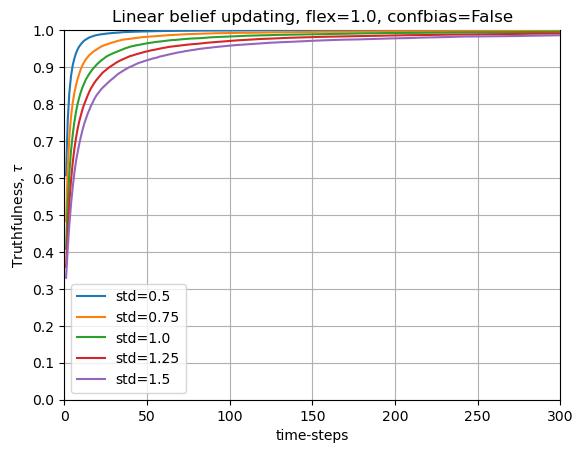

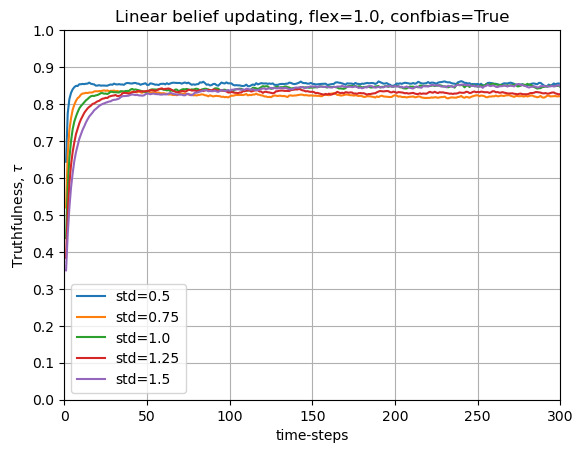

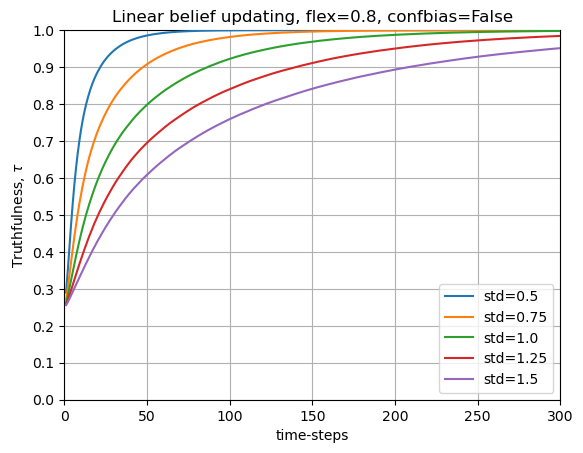

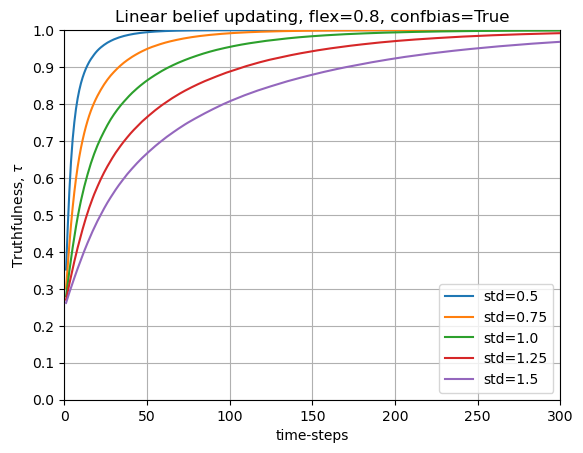

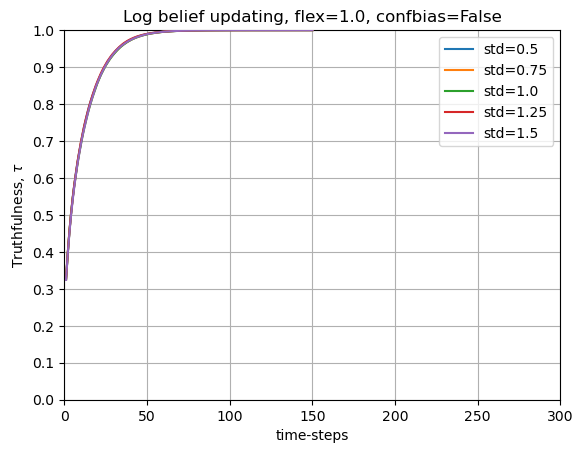

In [6]:
t = np.arange(1, len(T_std05), 1)

plt.figure()
plt.plot(t, T_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, confbias=False")
plt.show()

plt.figure()
plt.plot(t, T_confbias_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_confbias_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_confbias_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_confbias_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_confbias_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, confbias=True")
plt.show()

plt.figure()
plt.plot(t, T_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

plt.figure()
plt.plot(t, T_confbias_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_confbias_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_confbias_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_confbias_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_confbias_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=0.8, confbias=True")
plt.show()

plt.figure()
plt.plot(t[:len(T_log_std05)-1], T_log_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t[:len(T_log_std05)-1], T_log_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t[:len(T_log_std05)-1], T_log_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t[:len(T_log_std05)-1], T_log_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t[:len(T_log_std05)-1], T_log_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Log belief updating, flex=1.0, confbias=False")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (300,) and (299,)

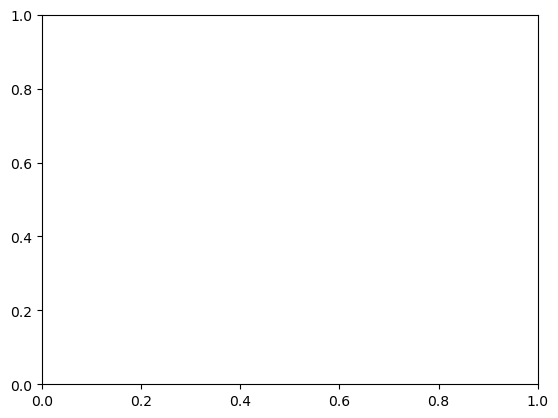

In [7]:
plt.figure()
plt.plot(t, CD_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=1.0, confbias=False")
plt.show()

plt.figure()
plt.plot(t, CD_confbias_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_confbias_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_confbias_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_confbias_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_confbias_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=1.0, confbias=True")
plt.show()

plt.figure()
plt.plot(t, CD_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

plt.figure()
plt.plot(t, CD_confbias_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_confbias_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_confbias_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_confbias_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_confbias_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

plt.figure()
plt.plot(t[:len(CD_log_std05)-1], CD_log_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t[:len(CD_log_std05)-1], CD_log_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t[:len(CD_log_std05)-1], CD_log_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t[:len(CD_log_std05)-1], CD_log_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t[:len(CD_log_std05)-1], CD_log_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Log belief updating")
plt.show()

In [ ]:
q_std05 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.5_10flex_confbias-False_T300_200sims_1.npz")
q_std075 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.75_10flex_confbias-False_T300_200sims_1.npz")
q_std10 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.0_10flex_confbias-False_T300_200sims_1.npz")
q_std125 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.25_10flex_confbias-False_T300_200sims_1.npz")
q_std15 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.5_10flex_confbias-False_T300_200sims_1.npz")

q_confbias_std05 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.5_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std075 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.75_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std10 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.0_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std125 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.25_10flex_confbias-True_T300_200sims_1.npz")
q_confbias_std15 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.5_10flex_confbias-True_T300_200sims_1.npz")

q_flex08_std05 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.5_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std075 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.75_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std10 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.0_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std125 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.25_8flex_confbias-False_T300_200sims_1.npz")
q_flex08_std15 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.5_8flex_confbias-False_T300_200sims_1.npz")

q_confbias_flex08_std05 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.5_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std075 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds0.75_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std10 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.0_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std125 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.25_8flex_confbias-True_T300_200sims_1.npz")
q_confbias_flex08_std15 = np.load("testing\DHT_N100_k10_PRICE_linbeliefs_gaussian-stds1.5_8flex_confbias-True_T300_200sims_1.npz")


T_std05 = truthfulness(q_std05['private'], 3)
T_std075 = truthfulness(q_std075['private'], 3)
T_std10 = truthfulness(q_std10['private'], 3)
T_std125 = truthfulness(q_std125['private'], 3)
T_std15 = truthfulness(q_std15['private'], 3)

T_confbias_std05 = truthfulness(q_confbias_std05['private'], 3)
T_confbias_std075 = truthfulness(q_confbias_std075['private'], 3)
T_confbias_std10 = truthfulness(q_confbias_std10['private'], 3)
T_confbias_std125 = truthfulness(q_confbias_std125['private'], 3)
T_confbias_std15 = truthfulness(q_confbias_std15['private'], 3)

T_flex08_std05 = truthfulness(q_flex08_std05['private'], 3)
T_flex08_std075 = truthfulness(q_flex08_std075['private'], 3)
T_flex08_std10 = truthfulness(q_flex08_std10['private'], 3)
T_flex08_std125 = truthfulness(q_flex08_std125['private'], 3)
T_flex08_std15 = truthfulness(q_flex08_std15['private'], 3)

T_confbias_flex08_std05 = truthfulness(q_confbias_flex08_std05['private'], 3)
T_confbias_flex08_std075 = truthfulness(q_confbias_flex08_std075['private'], 3)
T_confbias_flex08_std10 = truthfulness(q_confbias_flex08_std10['private'], 3)
T_confbias_flex08_std125 = truthfulness(q_confbias_flex08_std125['private'], 3)
T_confbias_flex08_std15 = truthfulness(q_confbias_flex08_std15['private'], 3)


CD_std05 = cognitive_dissonance(q_std05['private'], q_std05['public'])
CD_std075 = cognitive_dissonance(q_std075['private'], q_std075['public'])
CD_std10 = cognitive_dissonance(q_std10['private'], q_std10['public'])
CD_std125 = cognitive_dissonance(q_std125['private'], q_std125['public'])
CD_std15 = cognitive_dissonance(q_std15['private'], q_std15['public'])

CD_confbias_std05 = cognitive_dissonance(q_confbias_std05['private'], q_confbias_std05['public'])
CD_confbias_std075 = cognitive_dissonance(q_confbias_std075['private'], q_confbias_std075['public'])
CD_confbias_std10 = cognitive_dissonance(q_confbias_std10['private'], q_confbias_std10['public'])
CD_confbias_std125 = cognitive_dissonance(q_confbias_std125['private'], q_confbias_std125['public'])
CD_confbias_std15 = cognitive_dissonance(q_confbias_std15['private'], q_confbias_std15['public'])

CD_flex08_std05 = cognitive_dissonance(q_flex08_std05['private'], q_flex08_std05['public'])
CD_flex08_std075 = cognitive_dissonance(q_flex08_std075['private'], q_flex08_std075['public'])
CD_flex08_std10 = cognitive_dissonance(q_flex08_std10['private'], q_flex08_std10['public'])
CD_flex08_std125 = cognitive_dissonance(q_flex08_std125['private'], q_flex08_std125['public'])
CD_flex08_std15 = cognitive_dissonance(q_flex08_std15['private'], q_flex08_std15['public'])

CD_confbias_flex08_std05 = cognitive_dissonance(q_confbias_flex08_std05['private'], q_confbias_flex08_std05['public'])
CD_confbias_flex08_std075 = cognitive_dissonance(q_confbias_flex08_std075['private'], q_confbias_flex08_std075['public'])
CD_confbias_flex08_std10 = cognitive_dissonance(q_confbias_flex08_std10['private'], q_confbias_flex08_std10['public'])
CD_confbias_flex08_std125 = cognitive_dissonance(q_confbias_flex08_std125['private'], q_confbias_flex08_std125['public'])
CD_confbias_flex08_std15 = cognitive_dissonance(q_confbias_flex08_std15['private'], q_confbias_flex08_std15['public'])

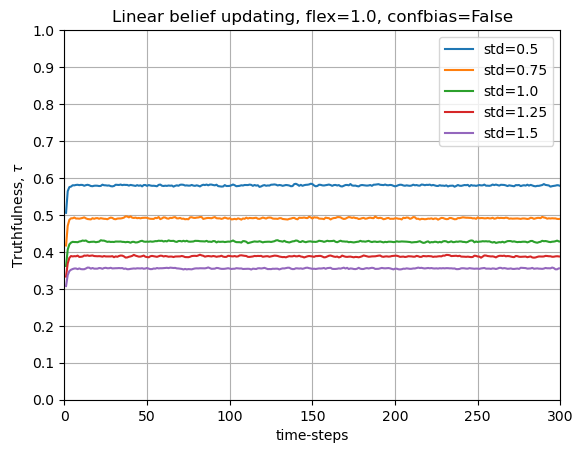

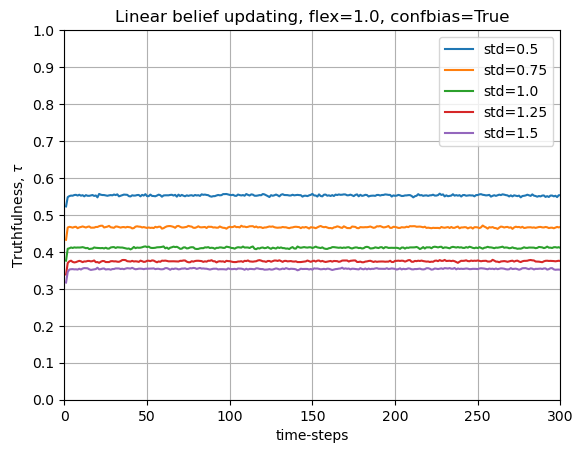

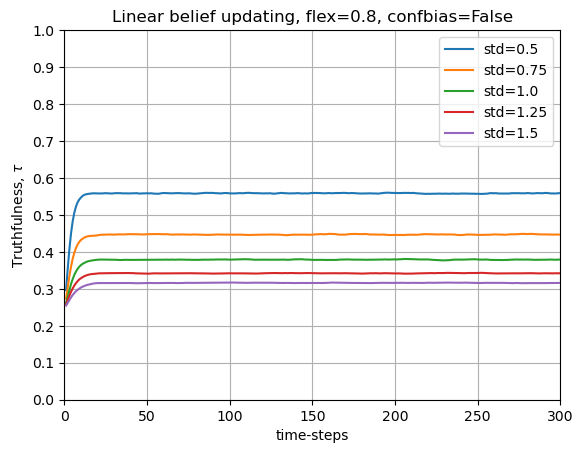

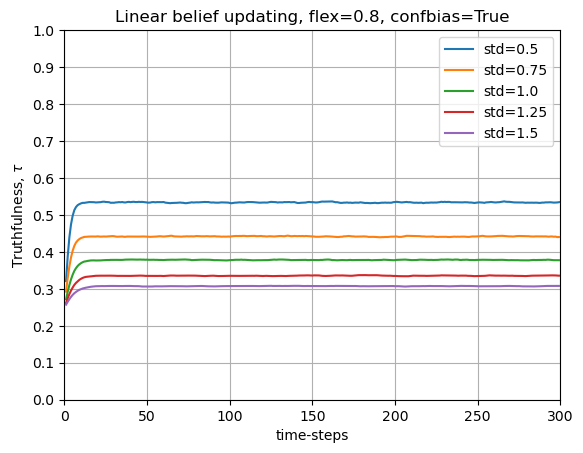

In [ ]:
t = np.arange(1, len(T_std05), 1)

plt.figure()
plt.plot(t, T_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, confbias=False")
plt.show()

plt.figure()
plt.plot(t, T_confbias_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_confbias_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_confbias_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_confbias_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_confbias_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=1.0, confbias=True")
plt.show()

plt.figure()
plt.plot(t, T_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

plt.figure()
plt.plot(t, T_confbias_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, T_confbias_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, T_confbias_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, T_confbias_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, T_confbias_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating, flex=0.8, confbias=True")
plt.show()

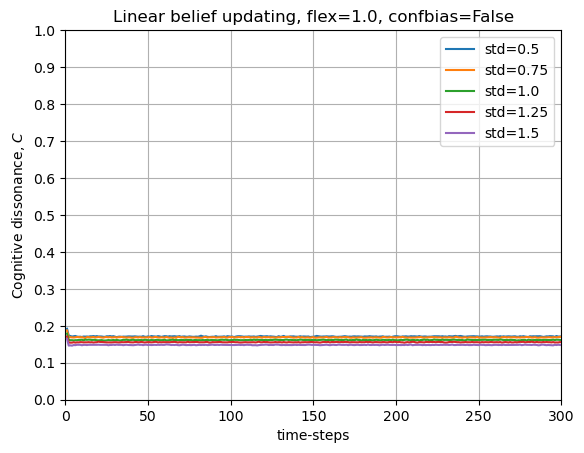

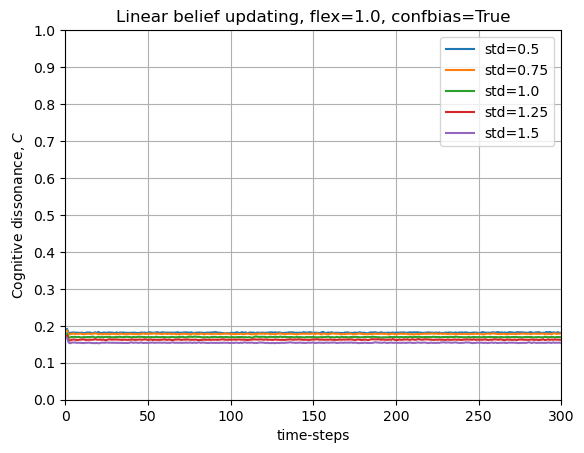

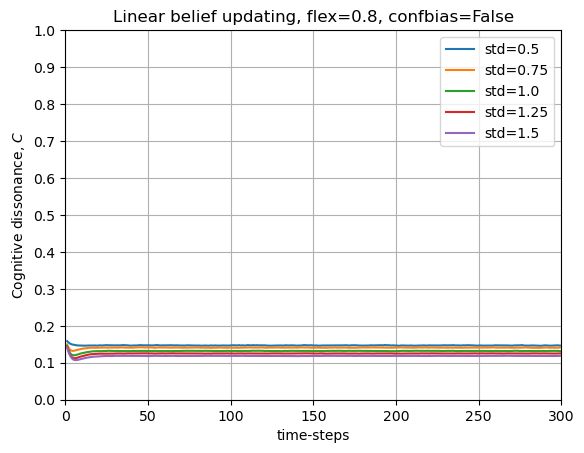

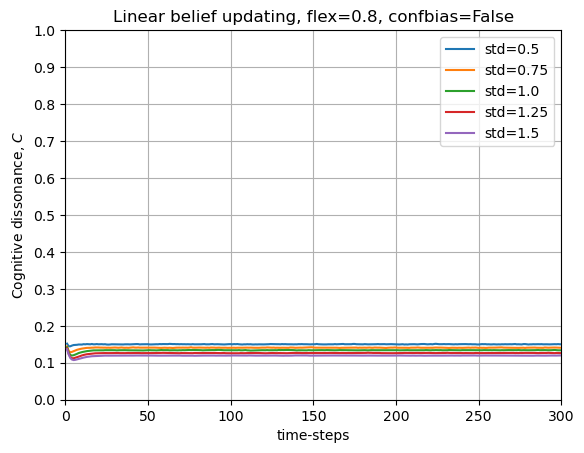

In [ ]:
plt.figure()
plt.plot(t, CD_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=1.0, confbias=False")
plt.show()

plt.figure()
plt.plot(t, CD_confbias_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_confbias_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_confbias_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_confbias_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_confbias_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=1.0, confbias=True")
plt.show()

plt.figure()
plt.plot(t, CD_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

plt.figure()
plt.plot(t, CD_confbias_flex08_std05[1::], label=r"std=0.5", zorder=5)
plt.plot(t, CD_confbias_flex08_std075[1::], label=r"std=0.75", zorder=6)
plt.plot(t, CD_confbias_flex08_std10[1::], label=r"std=1.0", zorder=7)
plt.plot(t, CD_confbias_flex08_std125[1::], label=r"std=1.25", zorder=8)
plt.plot(t, CD_confbias_flex08_std15[1::], label=r"std=1.5", zorder=9)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating, flex=0.8, confbias=False")
plt.show()

In [ ]:
# Testing gaussian stuff with linear belief updating
qg_lin_10flex_uniform = np.load("bullshittest_DHT_k100_ER_linbeliefs_gaussian_10flex_uniformweights_T300_500sims.npz")
qg_lin_08flex_uniform = np.load("bullshittest_DHT_k100_ER_linbeliefs_gaussian_08flex_uniformweights_T300_500sims.npz")
qg_lin_10flex_confbias = np.load("bullshittest_DHT_k100_ER_linbeliefs_gaussian_10flex_confbiasweights_T300_500sims.npz")
qg_lin_08flex_confbias = np.load("bullshittest_DHT_k100_ER_linbeliefs_gaussian_08flex_confbiasweights_T300_500sims.npz")

Tg_lin_10flex_uniform = truthfulness(qg_lin_10flex_uniform['private'], 3)
Tg_lin_08flex_uniform = truthfulness(qg_lin_08flex_uniform['private'], 3)
Tg_lin_10flex_confbias = truthfulness(qg_lin_10flex_confbias['private'], 3)
Tg_lin_08flex_confbias = truthfulness(qg_lin_08flex_confbias['private'], 3)

CDg_lin_10flex_uniform = cognitive_dissonance(qg_lin_10flex_uniform['private'], qg_lin_10flex_uniform['public'])
CDg_lin_08flex_uniform = cognitive_dissonance(qg_lin_08flex_uniform['private'], qg_lin_08flex_uniform['public'])
CDg_lin_10flex_confbias = cognitive_dissonance(qg_lin_10flex_confbias['private'], qg_lin_10flex_confbias['public'])
CDg_lin_08flex_confbias = cognitive_dissonance(qg_lin_08flex_confbias['private'], qg_lin_08flex_confbias['public'])

In [ ]:
# Testing gaussian stuff with log belief updating
qg_log_10flex_uniform = np.load("bullshittest_DHT_k100_ER_logbeliefs_gaussian_10flex_uniformweights_T300_500sims.npz")
qg_log_08flex_uniform = np.load("bullshittest_DHT_k100_ER_logbeliefs_gaussian_08flex_uniformweights_T300_500sims.npz")
qg_log_10flex_confbias = np.load("bullshittest_DHT_k100_ER_logbeliefs_gaussian_10flex_confbiasweights_T300_500sims.npz")
qg_log_08flex_confbias = np.load("bullshittest_DHT_k100_ER_logbeliefs_gaussian_08flex_confbiasweights_T300_500sims.npz")

Tg_log_10flex_uniform = truthfulness(qg_log_10flex_uniform['private'], 3)
Tg_log_08flex_uniform = truthfulness(qg_log_08flex_uniform['private'], 3)
Tg_log_10flex_confbias = truthfulness(qg_log_10flex_confbias['private'], 3)
Tg_log_08flex_confbias = truthfulness(qg_log_08flex_confbias['private'], 3)

CDg_log_10flex_uniform = cognitive_dissonance(qg_log_10flex_uniform['private'][:-1], qg_log_10flex_uniform['public'][1:])
CDg_log_08flex_uniform = cognitive_dissonance(qg_log_08flex_uniform['private'], qg_log_08flex_uniform['public'])
CDg_log_10flex_confbias = cognitive_dissonance(qg_log_10flex_confbias['private'], qg_log_10flex_confbias['public'])
CDg_log_08flex_confbias = cognitive_dissonance(qg_log_08flex_confbias['private'], qg_log_08flex_confbias['public'])

ValueError: x and y must have same first dimension, but have shapes (150,) and (300,)

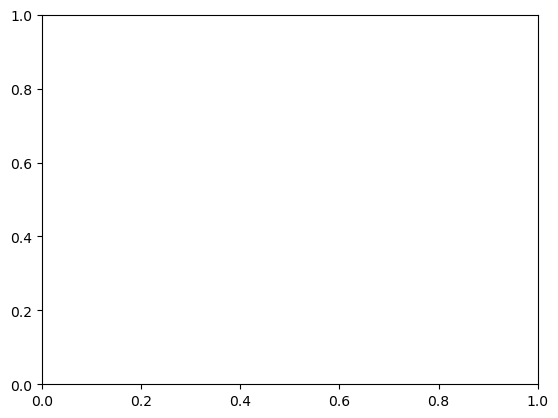

In [ ]:
plt.figure()
plt.plot(t, Tg_lin_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=5)
plt.plot(t, Tg_lin_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, Tg_lin_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, Tg_lin_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Linear belief updating")
plt.show()

plt.figure()
plt.plot(t, CDg_lin_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=5)
plt.plot(t, CDg_lin_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, CDg_lin_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, CDg_lin_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("Linear belief updating")
plt.show()

In [ ]:
plt.figure()
plt.plot(t, Tg_log_10flex_uniform[1::], label=r"1.0 flex, confbias", zorder=5)
plt.plot(t, Tg_log_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, Tg_log_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, Tg_log_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("log belief updating")
plt.show()

plt.figure()
plt.plot(t, CDg_log_10flex_uniform[1::], label=r"1.0 flex, confbias", zorder=5)
plt.plot(t, CDg_log_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, CDg_log_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, CDg_log_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.title("log belief updating")
plt.show()

In [ ]:
# Bernoulli plots

qb_08flex_confbias = np.load("test_DHT_k100_ER_logbeliefs_bernoulli_08flex_confbiasweights_T300_500sims.npz")
qb_08flex_uniform = np.load("test_DHT_k100_ER_logbeliefs_bernoulli_08flex_uniformweights_T300_500sims.npz")
qb_10flex_confbias = np.load("test_DHT_k100_ER_logbeliefs_bernoulli_10flex_confbiasweights_T300_500sims.npz")
qb_10flex_uniform = np.load("test_DHT_k100_ER_logbeliefs_bernoulli_10flex_uniformweights_T300_500sims.npz")
q1 = np.load("bullshittest_DHT_k100_ER_logbeliefs_bernoulli_10flex_uniformweights_T300_500sims.npz")
q2 = np.load("bullshittest_DHT_k100_ER_logbeliefs_bernoulli_08flex_uniformweights_T300_500sims.npz")

Tb_08flex_confbias = truthfulness(qb_08flex_confbias['private'], 3)
Tb_08flex_uniform = truthfulness(qb_08flex_uniform['private'], 3)
Tb_10flex_confbias = truthfulness(qb_10flex_confbias['private'], 3)
Tb_10flex_uniform = truthfulness(qb_10flex_uniform['private'], 3)
T1 = truthfulness(q['private'], 3)
T2 = truthfulness(q2['private'], 3)

CDb_08flex_confbias = cognitive_dissonance(qb_08flex_confbias['private'], qb_08flex_confbias['public'])
CDb_08flex_uniform = cognitive_dissonance(qb_08flex_uniform['private'], qb_08flex_confbias['public'])
CDb_10flex_confbias = cognitive_dissonance(qb_10flex_confbias['private'], qb_08flex_confbias['public'])
CDb_10flex_uniform = cognitive_dissonance(qb_10flex_uniform['private'], qb_08flex_confbias['public'])
CD1 = cognitive_dissonance(q['private'], q['public'])
CD2 = cognitive_dissonance(q2['private'], q2['public'])

In [ ]:
plt.figure()
plt.plot(t, Tb_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=5)
plt.plot(t, Tb_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, Tb_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, Tb_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=8)
plt.plot(t, T1[1::], label=r"bullshit 1.0 flex, uniform", zorder=9)
plt.plot(t, T2[1::], label=r"bullshit 0.8 flex, uniform", zorder=10)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.show()

plt.figure()
plt.plot(t, CDb_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=5)
plt.plot(t, CDb_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, CDb_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, CDb_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=8)
plt.plot(t, CD1[1::], label=r"bullshit 1.0 flex, uniform", zorder=9)
plt.plot(t, CD2[1::], label=r"bullshit 0.8 flex, uniform", zorder=10)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.show()

In [ ]:
# Gaussian plots

qg_08flex_confbias = np.load("test_DHT_k100_ER_logbeliefs_gaussian_08flex_confbiasweights_T300_500sims.npz")
qg_08flex_uniform = np.load("test_DHT_k100_ER_logbeliefs_gaussian_08flex_uniformweights_T300_500sims.npz")
qg_10flex_confbias = np.load("test_DHT_k100_ER_logbeliefs_gaussian_10flex_confbiasweights_T300_500sims.npz")
qg_10flex_uniform = np.load("test_DHT_k100_ER_logbeliefs_gaussian_10flex_uniformweights_T300_500sims.npz")

Tg_08flex_confbias = truthfulness(qg_08flex_confbias['private'], 3)
Tg_08flex_uniform = truthfulness(qg_08flex_uniform['private'], 3)
Tg_10flex_confbias = truthfulness(qg_10flex_confbias['private'], 3)
Tg_10flex_uniform = truthfulness(qg_10flex_uniform['private'], 3)

CDg_08flex_confbias = cognitive_dissonance(qg_08flex_confbias['private'], qg_08flex_confbias['public'])
CDg_08flex_uniform = cognitive_dissonance(qg_08flex_uniform['private'], qg_08flex_confbias['public'])
CDg_10flex_confbias = cognitive_dissonance(qg_10flex_confbias['private'], qg_08flex_confbias['public'])
CDg_10flex_uniform = cognitive_dissonance(qg_10flex_uniform['private'], qg_08flex_confbias['public'])

plt.figure()
plt.plot(t, Tg_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=5)
plt.plot(t, Tg_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, Tg_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, Tg_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.show()

plt.figure()
plt.plot(t, CDg_08flex_confbias[1::], label=r"0.8 flex, confbias", zorder=5)
plt.plot(t, CDg_08flex_uniform[1::], label=r"0.8 flex, uniform", zorder=6)
plt.plot(t, CDg_10flex_confbias[1::], label=r"1.0 flex, confbias", zorder=7)
plt.plot(t, CDg_10flex_uniform[1::], label=r"1.0 flex, uniform", zorder=8)
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Cognitive dissonance, $C$")
plt.show()

In [ ]:
# Specific agent plots
plt.figure(figsize=(8,6))
plt.plot(t, truthfulness(q1['private'], 0)[1::], label=r"$\theta_0$")
plt.plot(t, truthfulness(q1['private'], 1)[1::], label=r"$\theta_1$")
plt.plot(t, truthfulness(q1['private'], 2)[1::], label=r"$\theta_2$")
plt.plot(t, truthfulness(q1['private'], 3)[1::], label=r"$\theta_3$")
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Bernoulli signals, 1.0 flexibility, uniform weights")

plt.figure(figsize=(16,12))
plt.subplot(2, 2, 1)
plt.plot(t, truthfulness(qb_08flex_confbias['private'], 0)[1::], label=r"$\theta_0$")
plt.plot(t, truthfulness(qb_08flex_confbias['private'], 1)[1::], label=r"$\theta_1$")
plt.plot(t, truthfulness(qb_08flex_confbias['private'], 2)[1::], label=r"$\theta_2$")
plt.plot(t, truthfulness(qb_08flex_confbias['private'], 3)[1::], label=r"$\theta_3$")
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Bernoulli signals, 0.8 flexibility, confbias weights")

plt.subplot(2, 2, 2)
plt.plot(t, truthfulness(qb_08flex_uniform['private'], 0)[1::], label=r"$\theta_0$")
plt.plot(t, truthfulness(qb_08flex_uniform['private'], 1)[1::], label=r"$\theta_1$")
plt.plot(t, truthfulness(qb_08flex_uniform['private'], 2)[1::], label=r"$\theta_2$")
plt.plot(t, truthfulness(qb_08flex_uniform['private'], 3)[1::], label=r"$\theta_3$")
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Bernoulli signals, 0.8 flexibility, uniform weights")

plt.subplot(2, 2, 3)
plt.plot(t, truthfulness(qg_08flex_confbias['private'], 0)[1::], label=r"$\theta_0$")
plt.plot(t, truthfulness(qg_08flex_confbias['private'], 1)[1::], label=r"$\theta_1$")
plt.plot(t, truthfulness(qg_08flex_confbias['private'], 2)[1::], label=r"$\theta_2$")
plt.plot(t, truthfulness(qg_08flex_confbias['private'], 3)[1::], label=r"$\theta_3$")
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Gaussian signals, 0.8 flexibility, confbias weights")

plt.subplot(2, 2, 4)
plt.plot(t, truthfulness(qg_08flex_uniform['private'], 0)[1::], label=r"$\theta_0$")
plt.plot(t, truthfulness(qg_08flex_uniform['private'], 1)[1::], label=r"$\theta_1$")
plt.plot(t, truthfulness(qg_08flex_uniform['private'], 2)[1::], label=r"$\theta_2$")
plt.plot(t, truthfulness(qg_08flex_uniform['private'], 3)[1::], label=r"$\theta_3$")
plt.grid()
plt.xlim(0, np.max(t))
plt.xticks(np.arange(0, np.max(t)+1, 50))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.legend()
plt.xlabel("time-steps")
plt.ylabel(r"Truthfulness, $\tau$")
plt.title("Gaussian signals, 0.8 flexibility, uniform weights")

plt.show()

In [ ]:
import numpy as np
import numba
from metrics import gaussian_pdf

@numba.jit(nopython=True)
def get_likelihoods_gaussian(N, M, true_hypothesis):
    """
    DHT-style Gaussian likelihoods:
      - Each hypothesis k has a distinct mean (same for all agents)
      - All have the same standard deviation
      - Each agent i draws a signal X_i from the *true hypothesis*
      - Agents compute likelihoods under *all* hypotheses

    Args:
        N (int): number of agents
        M (int): number of hypotheses
        true_hypothesis (int): index of the true hypothesis

    Returns:
        likelihoods (N, M): per-agent likelihoods
    """
    std_draw = 0.5
    std_likelihood = 0.5
    means = np.linspace(-1.0, 1.0, M)
    likelihoods = np.zeros((N, M))

    for i in range(N):
        mu_true = means[true_hypothesis]
        print(mu_true)
        X_i = np.random.normal(mu_true, std_draw)
        for k in range(M):
            likelihoods[i, k] = gaussian_pdf(X_i, means[k], std_likelihood)

    return likelihoods

print(get_likelihoods_gaussian(10,4,3))